# Results Analysis — Elliptic Bitcoin (Fraud / Systemic-Risk GNN)

**Dissertation:** Graph Neural Networks for Systemic Risk and Fraud Detection in Credit Systems
**Track:** Fraud / systemic risk (homogeneous GNN node classification)
**Student:** Chandan Nagavolu — M.Tech, BITS Pilani WILP

Elliptic is a **homogeneous, temporal, pre-featurized** graph: ~204K Bitcoin
transactions, 166 features, directed payment edges, 49 time steps. We compare a
homogeneous GNN (GCN / GraphSAGE / GAT) against traditional baselines trained on
the *same* node features, and study the dataset's signature finding — the
**dark-market shutdown** — where detection collapses as behaviour shifts.

This notebook reads `reports/results_elliptic.csv` and the temporal-evaluation
outputs under `reports/elliptic/`, produced by `run_elliptic_pipeline.py`
(see `data/README.md`).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


def find_project_root(start: Path) -> Path:
    """Walk up from the notebook until the folder containing CLAUDE.md."""
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "CLAUDE.md").exists():
            return cand
    raise FileNotFoundError("Could not locate project root (CLAUDE.md).")


ROOT = find_project_root(Path.cwd())
print("Project root:", ROOT)

RESULTS_CSV = ROOT / "reports" / "results_elliptic.csv"
ELL_DIR = ROOT / "reports" / "elliptic"
FIG_DIR = ROOT / "reports" / "figures"

METRICS = ["roc_auc", "pr_auc", "f1", "mcc", "ks_statistic", "gini"]
PRETTY = {"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC", "f1": "F1",
          "mcc": "MCC", "ks_statistic": "KS", "gini": "Gini"}
HAVE_RESULTS = RESULTS_CSV.exists()
print("results table present:", HAVE_RESULTS)

Project root: D:\MTech\ProjectWork
results table present: True


## 1. Why these metrics?

Illicit transactions are ~2% of all nodes (~10% of *labelled* nodes), so this is
a **fraud-detection** problem and the imbalanced metrics lead:

| Metric | Why it matters here |
|---|---|
| **PR-AUC** | Area under precision-recall; the right summary for a rare positive class. |
| **MCC** | Balanced score over all four confusion cells; robust to imbalance. |
| **Illicit F1 / precision / recall** | Performance on the *illicit* class specifically. |
| **ROC-AUC** | Reported for comparability; optimistic under heavy imbalance. |

Unknown nodes (~77%) are kept for message passing but excluded from every metric.

In [2]:
if HAVE_RESULTS:
    raw = pd.read_csv(RESULTS_CSV, parse_dates=["timestamp"]).sort_values("timestamp")
    latest = raw.groupby(["model", "split"], as_index=False).tail(1).reset_index(drop=True)
    display(latest[["model", "split", "n_features", *METRICS]].round(4))
else:
    print("Run run_elliptic_pipeline.py first.")

,model,split,n_features,roc_auc,pr_auc,f1,mcc,ks_statistic,gini
0,logistic_regression,val,166,0.9036,0.5783,0.5218,0.4629,0.6668,0.8073
1,logistic_regression,test,166,0.8535,0.2120,0.2499,0.2761,0.5716,0.7069
2,random_forest,val,166,0.9983,0.9933,0.9713,0.9655,0.9691,0.9966
3,random_forest,test,166,0.9292,0.7888,0.7801,0.7685,0.7171,0.8583
4,xgboost,val,166,0.9980,0.9911,0.9686,0.9622,0.9710,0.9960
5,xgboost,test,166,0.9323,0.7997,0.7536,0.7369,0.7272,0.8646
6,graphsage,val,166,0.9791,0.9367,0.8738,0.8476,0.8832,0.9582
7,graphsage,test,166,0.8328,0.3703,0.4502,0.4102,0.5443,0.6656


## 2. Leaderboard — GNN vs traditional baselines (test span)

The key dissertation comparison. On Elliptic, a well-tuned **Random Forest** is a
famously strong baseline: the question is whether the payment-flow structure the
GNN exploits actually buys extra illicit-detection power.

,roc_auc,pr_auc,f1,mcc,ks_statistic,gini
model,,,,,,
logistic_regression,0.8535,0.2120,0.2499,0.2761,0.5716,0.7069
random_forest,0.9292,0.7888,0.7801,0.7685,0.7171,0.8583
xgboost,0.9323,0.7997,0.7536,0.7369,0.7272,0.8646
graphsage,0.8328,0.3703,0.4502,0.4102,0.5443,0.6656


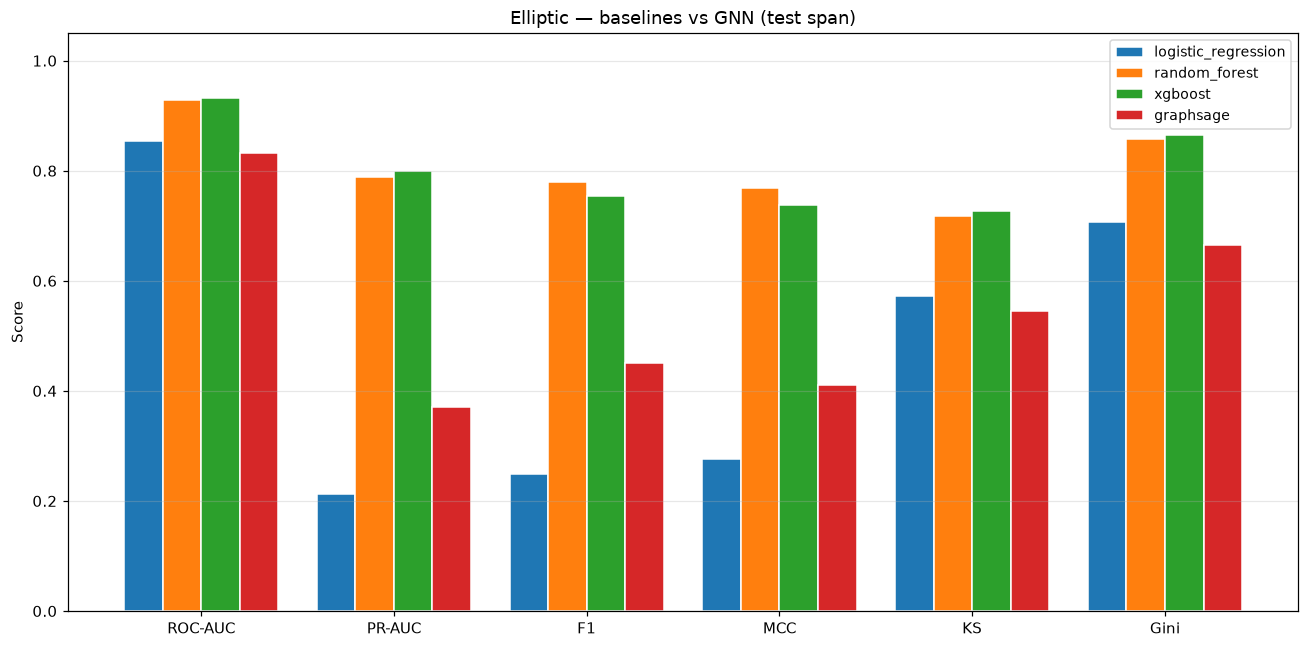

In [3]:
if HAVE_RESULTS:
    board = latest[latest.split == "test"].set_index("model")
    order = [m for m in ["logistic_regression", "random_forest", "xgboost", "gcn", "graphsage", "gat"] if m in board.index]
    board = board.reindex(order)
    display(board[METRICS].round(4))
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(METRICS)); width = 0.8 / max(len(order), 1)
    for i, model in enumerate(order):
        ax.bar(x + (i - (len(order)-1)/2) * width, board.loc[model, METRICS].values.astype(float),
               width, label=model, edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in METRICS]); ax.set_ylim(0, 1.05)
    ax.set_title("Elliptic — baselines vs GNN (test span)"); ax.set_ylabel("Score")
    ax.legend(loc="upper right", fontsize=9); ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout(); plt.show()

## 3. Illicit-class summary

From `reports/elliptic/elliptic_illicit_summary.csv` — the illicit-class F1,
precision and recall on the test span (the numbers most directly about catching
illicit activity), ranked by F1.

In [4]:
isum = ELL_DIR / "elliptic_illicit_summary.csv"
if isum.exists():
    display(pd.read_csv(isum).round(4))
else:
    print("Run src/evaluation/evaluate_elliptic.py first.")

,model,illicit_f1,illicit_precision,illicit_recall,pr_auc,roc_auc,mcc
0,random_forest,0.7801,0.8433,0.7258,0.7888,0.9292,0.7685
1,xgboost,0.7536,0.7662,0.7415,0.7997,0.9323,0.7369
2,graphsage,0.4502,0.4116,0.4968,0.3703,0.8328,0.4102
3,logistic_regression,0.2499,0.1440,0.9437,0.2120,0.8535,0.2761


## 4. The dark-market shutdown (temporal robustness)

Around **time step 43** a major darknet marketplace was shut down. Detection of
illicit transactions degrades sharply on the later steps for *every* model — a
concrete example of concept drift breaking a fraud model trained on the past.
This is the most-cited result on Elliptic and a direct systemic-risk talking
point.

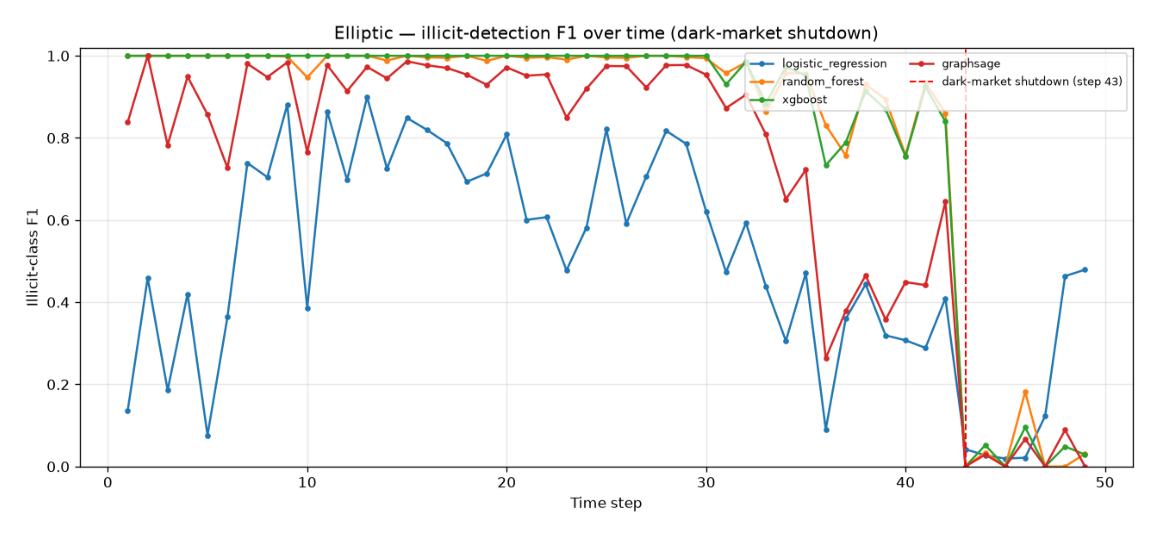

In [5]:
per_step_path = ELL_DIR / "per_timestep_f1.csv"
img = FIG_DIR / "elliptic_dark_market_f1.png"
if img.exists():
    fig, ax = plt.subplots(figsize=(11, 5)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    fig.tight_layout(); plt.show()
elif per_step_path.exists():
    ps = pd.read_csv(per_step_path)
    model_cols = [c for c in ps.columns if c not in ("time_step", "n_labeled", "n_illicit")]
    fig, ax = plt.subplots(figsize=(11, 5))
    for c in model_cols:
        ax.plot(ps["time_step"], ps[c], marker="o", ms=3, label=c)
    ax.axvline(43, color="red", ls="--", lw=1.2, label="dark-market (step 43)")
    ax.set_xlabel("Time step"); ax.set_ylabel("Illicit F1"); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3); fig.tight_layout(); plt.show()
else:
    print("Run the temporal evaluation first.")

## 5. Takeaways

- **Structure helps, but baselines are strong.** Random Forest on the node
  features alone is a hard-to-beat baseline; the GNN's value is whatever
  illicit-class lift it adds *on top* of that by using the payment graph.
- **Temporal robustness is the real story.** The step-43 collapse shows a static
  model degrades under behavioural shift — motivating temporal / drift-aware GNNs
  (e.g. EvolveGCN) as future work.
- **Consistent harness.** Baselines and the GNN share one feature matrix and one
  metric set, so the comparison is apples-to-apples.